In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import scipy.stats as stats


# define the luminosity function (broken power law)
def luminosity_function(L, L_break, alpha1, alpha2):
    if L < L_break:
        return (L / L_break)**(-alpha1)
    else:
        return (L / L_break)**(-alpha2)
        

In [13]:
#path = '/astrodata/romain/GA_SIMULATIONS/geneticgrbs_simulations_SPEWie4.3_rest_frame_lomax_norm_poly/norm_exp_relax_fast_cube_corrected_v1-N100/swift/'
L_iso_list_sim_total = []
for i in range(1,131):
    Liso_list_sim = np.loadtxt(f'sim_lum_func/Liso_list_sim{i}.txt')
    for l in Liso_list_sim:
        L_iso_list_sim_total.append(l)
    #plt.hist(Liso_list_sim, bins=np.logspace(50, 55, 20), alpha=0.5, label=f'sim {i}')

In [22]:
instrument = 'swift'
path = f'/astrodata/romain/GA_SIMULATIONS/geneticgrbs_simulations_SPEWie4.3_rest_frame_lomax_norm_poly_bpl/norm_exp_relax_fast_v1-N1000_bpl/{instrument}/'
N_grb = 5000
log_Liso = np.zeros(N_grb)
for i in range(N_grb):
    file_path = path + f'lc{i}energetics.txt'   
    log_Eiso,log_Liso[i],_,_,_=np.loadtxt(file_path)

In [15]:
instrument = 'batse'
path = f'/astrodata/romain/GA_SIMULATIONS/geneticgrbs_simulations_SPEWie4.3_rest_frame_lomax_norm_poly_bpl/norm_exp_relax_fast_v3-N1000/{instrument}/'
N_grb = 5000
log_Liso_batse = np.zeros(N_grb)
for i in range(N_grb):
    file_path = path + f'lc{i}energetics.txt'   
    log_Eiso,log_Liso_batse[i],_,_,_=np.loadtxt(file_path)

In [16]:
instrument = 'fermi'
path = f'/astrodata/romain/GA_SIMULATIONS/geneticgrbs_simulations_SPEWie4.3_rest_frame_lomax_norm_poly_bpl/norm_exp_relax_fast_v3-N1000/{instrument}/'
N_grb = 5000
log_Liso_fermi = np.zeros(N_grb)
for i in range(N_grb):
    file_path = path + f'lc{i}energetics.txt'   
    log_Eiso,log_Liso_fermi[i],_,_,_=np.loadtxt(file_path)

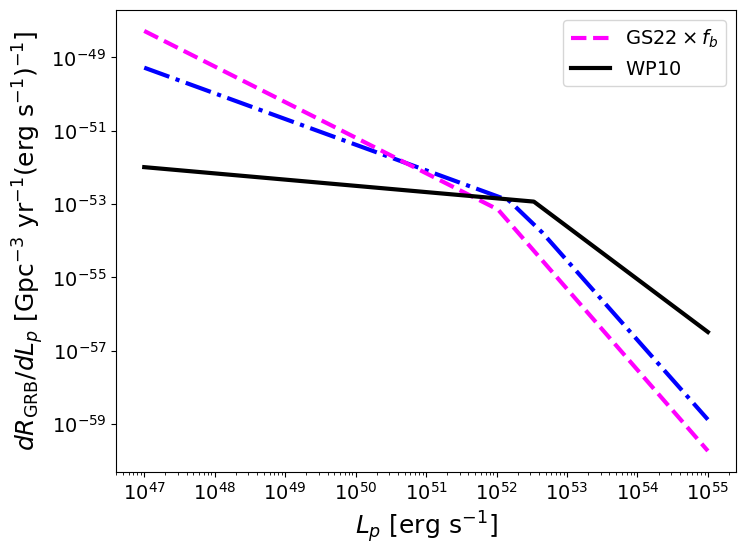

In [29]:
bins = np.logspace(47, 55, 18)  # Logarithmically spaced bins
Liso = 10**np.array(log_Liso)
cts,bins = np.histogram(Liso, bins=bins, density=True)

# Liso_batse = 10**np.array(log_Liso_batse)
# bins_batse = np.logspace(47, 55, 18)  # Logarithmically spaced bins
# cts_batse,bins_batse = np.histogram(Liso_batse, bins=bins_batse, density=True)

# Liso_fermi = 10**np.array(log_Liso_fermi)
# bins_fermi = np.logspace(47, 55, 18)  # Logarithmically spaced bins
# cts_fermi,bins_fermi = np.histogram(Liso_fermi, bins=bins_fermi, density=True)


Liso_th = np.array([luminosity_function(L, 10**(52.28), 0.70, 2.17) for L in bins])
Liso_th /= np.trapz(Liso_th, bins)  # Normalize the theoretical luminosity function


plt.figure(figsize=(8,6))
#plt.plot(bins[:-1], cts, color='b', label='Simulated GRBs (Swift)',lw=3)
plt.plot(bins, Liso_th, color='b',ls='-.',lw=3)

#plt.plot(bins_batse[:-1], cts_batse, color='r', label='Simulated GRBs (BATSE)',lw=3)
#plt.plot(bins_fermi[:-1], cts_fermi, color='g', label='Simulated GRBs (Fermi)',lw=3)
## lomax function
#cts_lomax, bins_lomax = np.histogram(samples, bins=bins, density=True)
#plt.plot(bins_lomax[:-1], cts_lomax, color='cyan', label='Lomax Fit',lw=3,ls='--')
#plt.step(bins[:-1], cts, color='b', alpha=0.5, label='Simulated GRBs',lw=3)
plt.xlabel(r'$L_{p}~{\rm[erg~s^{-1}]}$', size=18)
plt.ylabel(r'$dR_{\rm GRB}/dL_p~[\rm Gpc^{-3}$ yr$^{-1}({\rm erg~s^{-1}})^{-1}]$', size=18)
plt.xscale('log')
plt.yscale('log')

L_break = 10**(52.02)  # Break luminosity
alpha1 = 0.97  # Slope below the break
alpha2 = 2.21  # Slope above the break

L_values = np.logspace(47, 55, 1000)
LF_values = np.array([luminosity_function(L, L_break, alpha1, alpha2) for L in L_values])
LF_values /= np.trapz(LF_values, L_values)  # Normalize the luminosity function

LF_values *= (79/100)
plt.plot(L_values, LF_values, color='magenta',ls='--', label=r'${\rm GS22}\times f_b$',lw=3)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

LF_valuesWP10 = np.array([luminosity_function(L, 10**(52.53), 0.17, 1.44) for L in L_values])
LF_valuesWP10 /= np.trapz(LF_valuesWP10, L_values)
LF_valuesWP10 *= 1.3 

plt.plot(L_values, LF_valuesWP10, color='k', label=r'${\rm WP10}$',lw=3)

plt.legend(fontsize=14)
#plt.title('Luminosity Function of Simulated GRBs')
os.makedirs(f'{instrument}_results', exist_ok=True)
plt.savefig(f'{instrument}_results/luminosity_function_simulated_GRBs_bpl_{instrument}.pdf',bbox_inches='tight')

In [27]:
cts_batse

array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan])

In [12]:
x_e    = 4.454e+52
alpha    = 2.910
import scipy.stats
samples = scipy.stats.lomax(c=alpha, scale=x_e).rvs(size=int(1e6))
len(samples[samples>2e54])


15

In [48]:
np.max(samples)

1.7042804314225473e+55

In [43]:
import scipy.stats
p = scipy.stats.lomax(c=alpha1, scale=L_break).pdf(Liso)

# generate random samples from the Lomax distribution
samples = scipy.stats.lomax(c=alpha1, scale=L_break).rvs(size=int(1e6))
samples
#plt.figure(figsize=(8,6))
#plt.plot(Liso, p, 'o', label='Lomax PDF')

array([3.71320852e+51, 9.68425015e+51, 1.16065427e+52, ...,
       2.78786169e+51, 2.28290299e+52, 8.37473017e+53])